# 11 — SOM Pixel Assignment

Load the trained SOM codebook from `10_som_training.ipynb`,
assign every valid pixel to its nearest BMU, and save the
landscape patch map.

**Input**: `final_som_codebook.pkl`, `som_production.index`,
feature stack from S3

**Output**: patch map saved to S3 Zarr

### Setup

In [1]:
import config
import gc
import json
import pickle
import numpy as np
import xarray as xr
import rioxarray
import s3fs
from s3_utils import load_zarr

# Load feature selection
with open('selected_features.json') as f:
    feature_names = json.load(f)
n_features = len(feature_names)

# Load scaler (fitted on all 21 features) and subset to selected
s3 = s3fs.S3FileSystem(anon=False)
prep = config.S3_PROCESSED + '/som_prep'
s3.get(f'{prep}/scaler.pkl', '/tmp/scaler.pkl')
with open('/tmp/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

s3.get(f'{prep}/feature_names.json', '/tmp/feature_names.json')
with open('/tmp/feature_names.json') as f:
    all_feature_names = json.load(f)

sel_idx = [all_feature_names.index(f) for f in feature_names]
scaler.center_ = scaler.center_[sel_idx]
scaler.scale_ = scaler.scale_[sel_idx]
scaler.n_features_in_ = n_features

# Grid metadata
s3.get(f'{prep}/grid_meta.json', '/tmp/grid_meta.json')
with open('/tmp/grid_meta.json') as f:
    grid_meta = json.load(f)
grid_shape = tuple(grid_meta['grid_shape'])
n_pixels = grid_meta['n_pixels']

# Valid indices
s3.get(f'{prep}/valid_indices.npy', '/tmp/valid_indices.npy')
valid_indices = np.load('/tmp/valid_indices.npy')
n_valid = len(valid_indices)

print(f'{n_features} features: {feature_names}')
print(f'Grid: {grid_shape}, valid: {n_valid:,} / {n_pixels:,}')


12 features: ['bio1', 'bio15', 'human_footprint', 'bio18', 'bio4', 'bio12', 'lc_built-up', 'ndvi_max', 'slope', 'canopy_height', 'forest_edge_dist', 'twi']
Grid: (9010, 17810), valid: 157,901,556 / 160,468,100


### Post-scale function (must match training)

In [2]:
def post_scale(X):
    """Domain-specific adjustments after RobustScaler."""
    X = X.copy()
    if 'forest_edge_dist' in feature_names:
        X[:, feature_names.index('forest_edge_dist')] = np.clip(
            X[:, feature_names.index('forest_edge_dist')], -5, 5)
    for name in feature_names:
        if name.startswith('lc_'):
            X[:, feature_names.index(name)] *= 3.0
    return np.clip(X, -5, 5)


### Assign and save in row-chunks

Process the grid in horizontal strips (e.g., 500 rows at a time).
Each strip is assigned, written to a local numpy memmap, and progress
is saved. If the connection drops, restart from the last completed strip.

In [3]:
import faiss
import time
import os

# Load model
index = faiss.read_index('som_production.index')
print(f'FAISS index: {index.ntotal} vectors')

# Load feature stack
ds = load_zarr(config.FEATURE_STACK_ZARR)
ref = ds[feature_names[0]]
n_rows, n_cols = grid_shape

# Output memmap — survives kernel restarts
MEMMAP_PATH = './.tmp/patch_map.dat'
ROW_CHUNK = 500
PROGRESS_PATH = './.tmp/patch_map_progress.txt'

# Create or resume memmap
if os.path.exists(MEMMAP_PATH) and os.path.exists(PROGRESS_PATH):
    patch_map = np.memmap(MEMMAP_PATH, dtype=np.int32, mode='r+', shape=(n_rows, n_cols))
    with open(PROGRESS_PATH) as f:
        start_row = int(f.read().strip())
    print(f'Resuming from row {start_row}')
else:
    patch_map = np.memmap(MEMMAP_PATH, dtype=np.int32, mode='w+', shape=(n_rows, n_cols))
    patch_map[:] = -1
    start_row = 0
    print('Starting fresh')

t0 = time.time()
total_assigned = 0

for row_start in range(start_row, n_rows, ROW_CHUNK):
    row_end = min(row_start + ROW_CHUNK, n_rows)

    # Load this strip of features
    strip = np.empty((row_end - row_start, n_cols, n_features), dtype=np.float32)
    for j, name in enumerate(feature_names):
        strip[:, :, j] = ds[name].values[row_start:row_end, :]

    # Flatten to (pixels_in_strip, n_features)
    flat = strip.reshape(-1, n_features)
    del strip

    # Find valid pixels (no NaN)
    valid = np.isfinite(flat).all(axis=1)
    valid_idx = np.where(valid)[0]

    if len(valid_idx) > 0:
        # Scale + post-process
        X_chunk = post_scale(scaler.transform(flat[valid_idx])).astype(np.float32)

        # FAISS nearest BMU
        _, labels = index.search(X_chunk, k=1)
        labels = labels.flatten().astype(np.int32)

        # Write to memmap
        strip_labels = np.full(flat.shape[0], -1, dtype=np.int32)
        strip_labels[valid_idx] = labels
        patch_map[row_start:row_end, :] = strip_labels.reshape(row_end - row_start, n_cols)
        total_assigned += len(valid_idx)

        del X_chunk, labels
    del flat

    # Save progress
    patch_map.flush()
    with open(PROGRESS_PATH, 'w') as f:
        f.write(str(row_end))

    elapsed = time.time() - t0
    pct = row_end / n_rows * 100
    eta = elapsed / max(pct, 0.1) * (100 - pct)
    if (row_start // ROW_CHUNK) % 2 == 0:
        print(f'  Rows {row_end:>5d}/{n_rows}  ({pct:5.1f}%)  '
              f'assigned={total_assigned:,}  elapsed={elapsed:.0f}s  ETA={eta:.0f}s')

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.0f}s. Total assigned: {total_assigned:,}')


FAISS index: 4096 vectors
Resuming from row 9010

Done in 0s. Total assigned: 0


### Convert memmap to xarray and save to S3

In [5]:
from s3_utils import save_zarr

# Read the completed memmap
patch_map = np.memmap(MEMMAP_PATH, dtype=np.int32, mode='r', shape=(n_rows, n_cols))

patch_da = xr.DataArray(
    np.array(patch_map),  # copy from memmap to regular array
    dims=ref.dims, coords=ref.coords, name='patch_id',
).rio.write_crs('EPSG:4326')

save_zarr(patch_da, config.S3_PROCESSED + '/som/patch_map_30m.zarr', name='patch_id')
print(f'Saved: {patch_da.shape}, unique patches: {len(np.unique(patch_da.values[patch_da.values >= 0])):,}')

# Cleanup temp files
import os
#os.remove(MEMMAP_PATH)
#os.remove(PROGRESS_PATH)


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved → s3://km-cas-datalake/processed/som/patch_map_30m.zarr
Saved: (9010, 17810), unique patches: 4,096


### Visualize

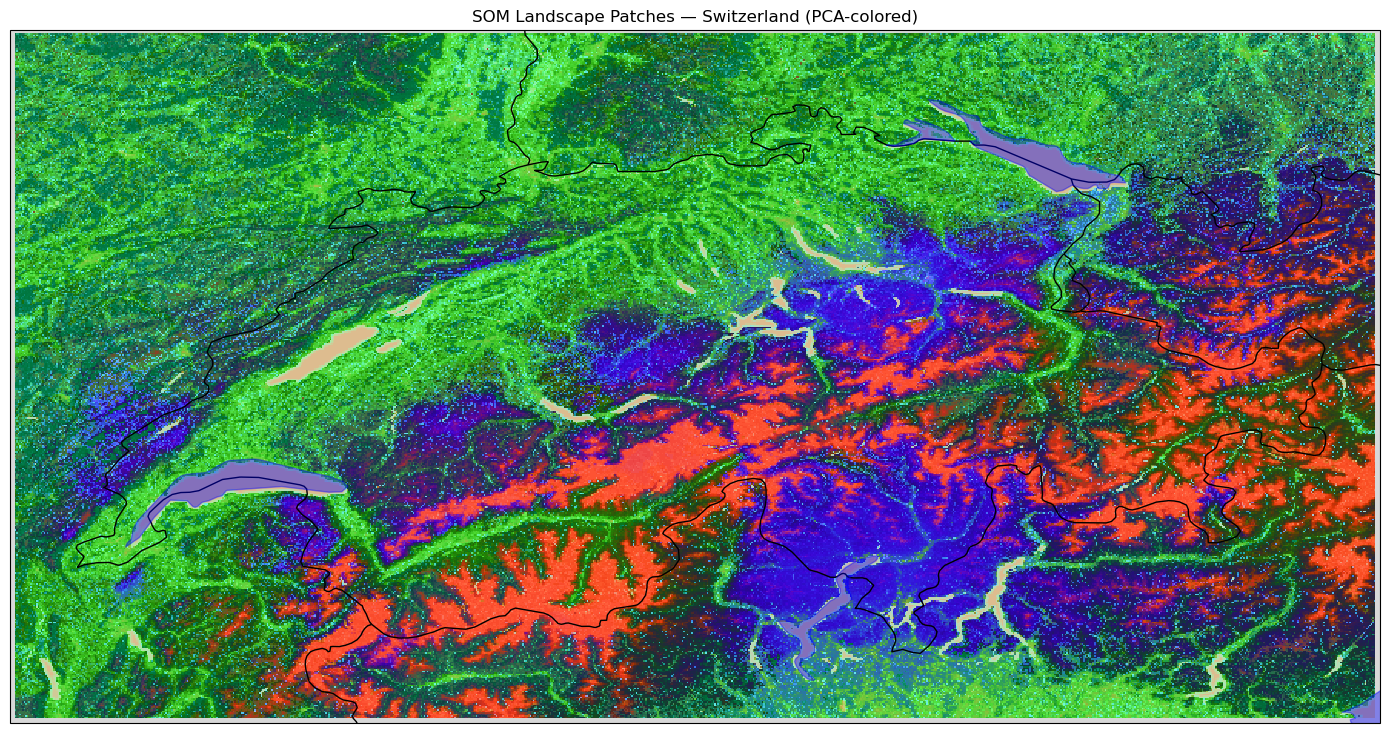

In [6]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geo_utils import BOUNDS, apply_map_decor

# PCA-based colormap from codebook
with open('final_som_codebook.pkl', 'rb') as f:
    cb = pickle.load(f)

pca = PCA(n_components=3)
cb_3d = pca.fit_transform(cb)
for c in range(3):
    lo, hi = cb_3d[:, c].min(), cb_3d[:, c].max()
    cb_3d[:, c] = (cb_3d[:, c] - lo) / (hi - lo + 1e-8)

n_units = cb.shape[0]
colors = np.vstack([[0.85, 0.85, 0.85], cb_3d])
som_cmap = mcolors.ListedColormap(colors)

# Full Switzerland — downsample for rendering
step = 20
patch_shifted = (patch_da.values + 1)[::step, ::step]

fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.imshow(
    patch_shifted,
    cmap=som_cmap,
    vmin=0, vmax=n_units,
    extent=[BOUNDS['lon_min'], BOUNDS['lon_max'],
            BOUNDS['lat_min'], BOUNDS['lat_max']],
    origin='upper',
    interpolation='nearest',
    transform=ccrs.PlateCarree(),
)
apply_map_decor(ax, 'SOM Landscape Patches — Switzerland (PCA-colored)')
plt.tight_layout()
plt.show()


### ROI check: North of Bern

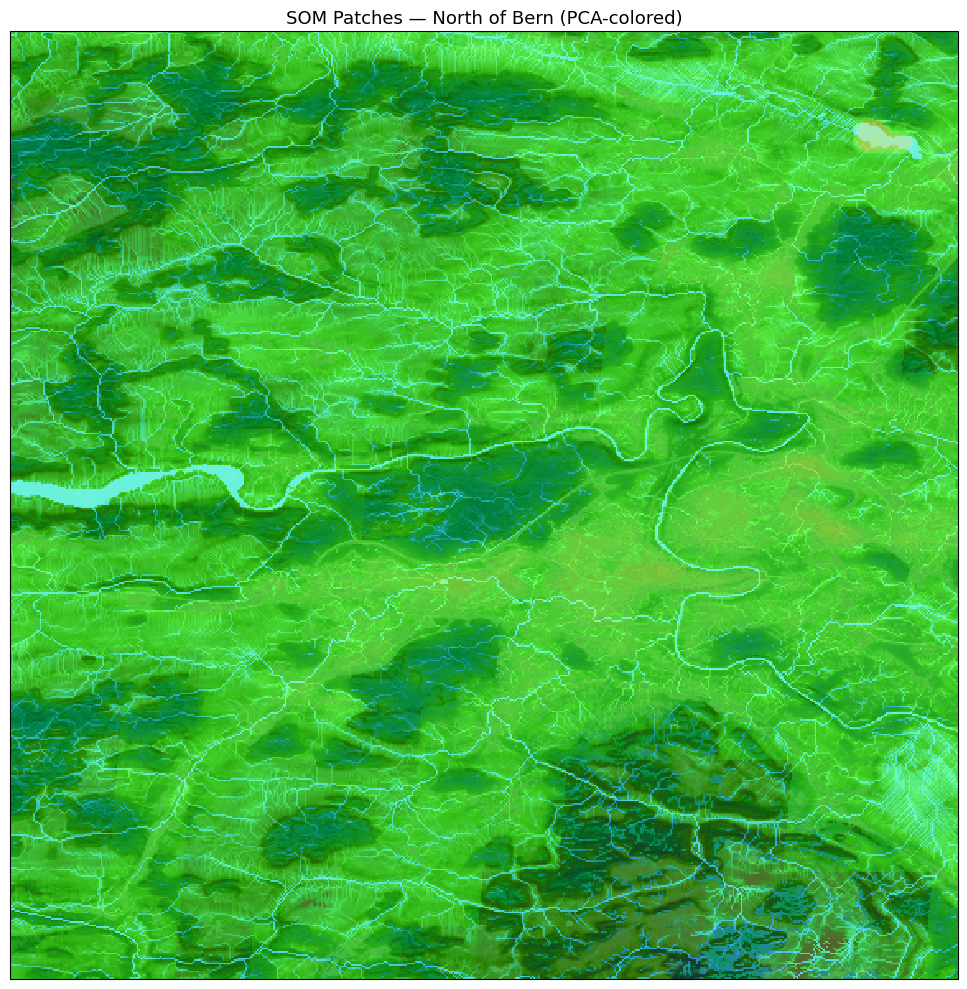

In [7]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load codebook and build a PCA-based colormap
with open('final_som_codebook.pkl', 'rb') as f:
    cb = pickle.load(f)  # (n_units, n_features)

# Project codebook to 3D via PCA → use as RGB
pca = PCA(n_components=3)
cb_3d = pca.fit_transform(cb)

# Normalize each component to [0, 1] for RGB
for c in range(3):
    lo, hi = cb_3d[:, c].min(), cb_3d[:, c].max()
    cb_3d[:, c] = (cb_3d[:, c] - lo) / (hi - lo + 1e-8)

# Build a ListedColormap: color[i] = RGB of neuron i
# Add grey for nodata (patch_id = -1 mapped to index 0 after shift)
n_units = cb.shape[0]
colors = np.vstack([[0.85, 0.85, 0.85], cb_3d])  # index 0 = grey (nodata)
som_cmap = mcolors.ListedColormap(colors)

# Shift patch IDs: -1 → 0 (nodata), 0 → 1, etc.
patch_shifted = patch_da.values + 1  # now 0 = nodata, 1..4096 = neurons

# ROI
roi_bern = {
    'lon_min': 7.332136, 'lon_max': 7.492136,
    'lat_min': 46.880651, 'lat_max': 47.040651,
}

# Clip to ROI using coordinate slicing
roi_da = patch_da.sel(
    y=slice(roi_bern['lat_max'], roi_bern['lat_min']),
    x=slice(roi_bern['lon_min'], roi_bern['lon_max']),
)
roi_shifted = roi_da.values + 1

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.imshow(
    roi_shifted,
    cmap=som_cmap,
    vmin=0, vmax=n_units,
    extent=[roi_bern['lon_min'], roi_bern['lon_max'],
            roi_bern['lat_min'], roi_bern['lat_max']],
    origin='upper',
    interpolation='nearest',
    transform=ccrs.PlateCarree(),
)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5)
ax.add_feature(cfeature.LAKES.with_scale('10m'), alpha=0.3, color='blue')
ax.set_extent([roi_bern['lon_min'], roi_bern['lon_max'],
               roi_bern['lat_min'], roi_bern['lat_max']])
ax.set_title('SOM Patches — North of Bern (PCA-colored)', fontsize=13)
plt.tight_layout()
plt.show()
